In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import plotconfig
import datetime

In [2]:
def rate_2_mbps(token):
    if "Mbps" in token:
        return float(token.split("Mbps")[0])
    if "Gbps" in token:
        return float(token.split("Gbps")[0]) * 1000
    if "kbps" in token:
        return float(token.split("kbps")[0]) / 1000
    if "bps" in token:
        return float(token.split("bps")[0]) / 1000000
    return token

def parse_line(line, bbr_version = "", starttime = None):
    line = line.replace("\t", "")
    ts = float(line.split(",")[0])
    try:
        line = line.split("bbr"+bbr_version, maxsplit=1)[1]
    except:
        return None, None
    line = line.replace("delivery_rate ", "delivery_rate:")
    line = line.replace("pacing_rate ", "pacing_rate:")
    line = line.replace("send ", "send:")
    line = line.replace("app_limited", "app_limited:1")
    line = line.replace("\n", "")

    tokens = [t for t in line.split(" ") if t != ""]
    d = {t.split(":", maxsplit=1)[0]:t.split(":", maxsplit=1)[1] for t in tokens if len(t.split(":")) > 1}
    dt = datetime.datetime.fromtimestamp(ts)
    epoch = datetime.datetime(1970, 1, 1)
    d["ts"] = dt - epoch
    d["ts_int"] = d["ts"].total_seconds()
    if starttime is None:
        starttime = d["ts_int"]
        d["relative_sec"] = 0
    else:
        d["relative_sec"] = d["ts_int"] - starttime
    d["bbr"] = d["bbr"].replace("(", "").replace(")", "")
    d["bbr"] = d["bbr"].split(",")
    d["bbr"] = {t.split(":", maxsplit=1)[0]:t.split(":", maxsplit=1)[1] for t in d["bbr"]}
    
    d["bbr"]["bw"] = rate_2_mbps(d["bbr"]["bw"])
    d["send"] = rate_2_mbps(d["send"])
    d["pacing_rate"] = rate_2_mbps(d["pacing_rate"])
    try:
        d["delivery_rate"] = rate_2_mbps(d["delivery_rate"])
    except:
        return None, None
    d["bw_delivery_diff"] = d["bbr"]["bw"] - d["delivery_rate"]
    d["inflight"] = int(d["bytes_sent"]) - int(d["bytes_acked"])
    d["target_inflight"] = (float(d["bbr"]["pacing_gain"]) * (d["bbr"]["bw"]*1000000/8))*0.015
    d["inflight_rel"] = float(d["inflight"]/d["target_inflight"])
    d["current_bdp"] = (float(d["bbr"]["bw"])*1000000/8) * (float(d["bbr"]["mrtt"])*0.001)
    d["inflight_current_bdp"] = d["inflight"] / d["current_bdp"]
    
    for bbr_metric in d["bbr"]:
        d[f"bbr_{bbr_metric}"] = float(d["bbr"][bbr_metric])
    del d["bbr"]

    return d, starttime

In [3]:
def parse_lines(lines: list, bbr_version=""):
    res = {}
    starttime = None
    for line in lines:
        d, starttime = parse_line(line, bbr_version, starttime)
        if d is not None:
            res = {k:res.get(k, [])+[v] for k, v in d.items()}
    return res

def set_invisible(ax):
    ax.set_yticklabels([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_color('white')
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_color('white')
    ax.tick_params(axis='both', which='major', labelsize=plotconfig.FONT_SIZE-2, color="white",labelcolor="white")
    return ax

In [4]:
colors = {"bbr_bw": plotconfig.COLORS[0], "delivery_rate": plotconfig.COLORS[2], "pacing_rate": plotconfig.COLORS[1], "bbr_mrtt": plotconfig.COLORS[3], "bbr_pacing_gain": plotconfig.COLORS[1], "bbr_cwnd_gain": plotconfig.COLORS[0], "inflight_current_bdp": plotconfig.COLORS[0], "inflight": "red"}
label = {"bbr_bw": "bw estimate", "bbr_pacing_gain": "pacing gain", "bbr_cwnd_gain": "cwnd gain", "delivery_rate": "delivery rate","pacing_rate":"pacing rate", "inflight": "inflight",  "bbr_mrtt": "RTT"}


def new_plot_all(d_list, max_x = None, max_y = None, titles=[], savefig = False):
    if savefig:
        mpl.use('agg')
    plotconfig.configure_conext()
    width = plotconfig.pt2inch(plotconfig.COLUMN_WIDTH)
    height = (width/5.5)*1.7
    FIG_SIZE = (width, height)
    fig, axes = plt.subplots(2, len(d_list), sharex=True, figsize = FIG_SIZE,constrained_layout=True)
    fig.set_constrained_layout_pads(
        w_pad=0.02,
    )
    

    for col, d in enumerate(d_list):
        metric = "pacing_rate"
        axes[0][col].scatter(d["relative_sec"], d[metric], label = label[metric] , color = colors[metric], alpha=0.6, s=1)
        metric = "delivery_rate"
        axes[0][col].scatter(d["relative_sec"], d[metric], label = label[metric] , color = colors[metric], alpha=0.6, s=1)
        metric = "bbr_bw"
        axes[0][col].scatter(d["relative_sec"], d[metric], label = label[metric] , color = colors[metric], alpha=0.6, s=1)
        
        if max_x:
            axes[0][col].set_xlim(-0.2, max_x)
        if max_y:
            axes[0][col].set_ylim(-5, max_y)

        metric = "inflight_current_bdp"
        axes[1][col].scatter(d["relative_sec"], d[metric], color = colors[metric], alpha=0.6, s=1)
        axes[1][col].axhline(y=1, color="g", label="1 BDP", linewidth=0.5)
        axes[1][col].set_ylim(-0.1,3.1)
        axes[1][col].set_yticks([0,1,2,3],[0,1,2,3])

        axes[0][col].tick_params(axis='both', which='major', labelsize=plotconfig.FONT_SIZE-2)
        axes[1][col].tick_params(axis='both', which='major', labelsize=plotconfig.FONT_SIZE-2)

        if col == 0:
            axes[0][col].set_ylabel("rate [mbps]", fontsize=plotconfig.FONT_SIZE-2)
            axes[1][col].set_ylabel("inflight [bdp]", fontsize=plotconfig.FONT_SIZE-2, labelpad=7)
        else:
            axes[0][col].set_yticklabels([])
            axes[1][col].set_yticklabels([])
        
        if col == len(d_list)-1:
            axes[0][col].legend(fontsize=plotconfig.FONT_SIZE-2, loc="upper right")
            axes[1][col].legend(fontsize=plotconfig.FONT_SIZE-2, loc="upper right")

        axes[0][col].set_title(titles[col], fontsize=plotconfig.FONT_SIZE-2, pad=1)
        axes[1][col].set_xlabel("run time [sec]", fontsize=plotconfig.FONT_SIZE-2)
        

    if savefig:
        plt.savefig(f"figures/figure_9.pdf", format="pdf")
    else:
        plt.show()

<>:7: SyntaxWarning: invalid escape sequence '\%'
<>:13: SyntaxWarning: invalid escape sequence '\%'
<>:18: SyntaxWarning: invalid escape sequence '\%'
<>:24: SyntaxWarning: invalid escape sequence '\%'
<>:7: SyntaxWarning: invalid escape sequence '\%'
<>:13: SyntaxWarning: invalid escape sequence '\%'
<>:18: SyntaxWarning: invalid escape sequence '\%'
<>:24: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_225339/928366607.py:7: SyntaxWarning: invalid escape sequence '\%'
  titles.append("(a) BBRv3, 100\% CPU")
/tmp/ipykernel_225339/928366607.py:13: SyntaxWarning: invalid escape sequence '\%'
  titles.append("(b) BBRv1, 100\% CPU")
/tmp/ipykernel_225339/928366607.py:18: SyntaxWarning: invalid escape sequence '\%'
  titles.append("(c) BBRv3, 25\% CPU")
/tmp/ipykernel_225339/928366607.py:24: SyntaxWarning: invalid escape sequence '\%'
  titles.append("(d) BBRv1, 25\% CPU")


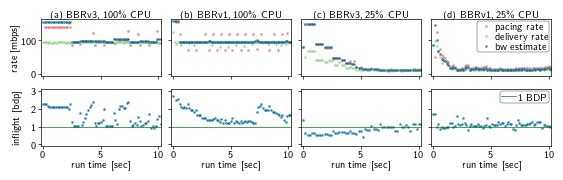

In [5]:
# BBRv1/v3 all
d_list = []
titles = []
with open("../data/socket_data/ss_no_scheduling_bbr3.log", "r") as f:
    data = f.readlines()
d_list.append(parse_lines(data))
titles.append("(a) BBRv3, 100\% CPU")

# ss_patched_25_scheduling_bbr3_3
with open("../data/socket_data/ss_no_scheduling_bbr1.log", "r") as f:
    data = f.readlines()
d_list.append(parse_lines(data, "1"))
titles.append("(b) BBRv1, 100\% CPU")

with open("../data/socket_data/ss_25_scheduling_bbr3.log", "r") as f:
    data = f.readlines()
d_list.append(parse_lines(data))
titles.append("(c) BBRv3, 25\% CPU")

# ss_patched_25_scheduling_bbr3_3
with open("../data/socket_data/ss_25_scheduling_bbr1.log", "r") as f:
    data = f.readlines()
d_list.append(parse_lines(data))
titles.append("(d) BBRv1, 25\% CPU")

new_plot_all(d_list, max_x=10.2, max_y=165, titles=titles, savefig=True)